<a href="https://colab.research.google.com/github/RamSudan04/Consumer.py/blob/main/Predicting_Severe_Psychiatric_Comorbidity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

# You might need to re-upload your .zip file if the session is new
from google.colab import files
uploaded = files.upload()

# Get the name of the uploaded zip file and extract the CSV
zip_file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    csv_file_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    print(f"Extracting and loading: {csv_file_name}")
    with z.open(csv_file_name) as f:
        # Read the CSV with semicolon separator
        df = pd.read_csv(f, sep=';')

print("\nDataset loaded successfully into the 'df' DataFrame!")

Saving archive (2).zip to archive (2) (1).zip
Extracting and loading: 2012BASECOPSIAD ingles (2).csv

Dataset loaded successfully into the 'df' DataFrame!


In [ ]:
# Run this cell to upload your .zip file from your computer
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [ ]:
# Get the name of the uploaded zip file and extract the CSV
zip_file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    csv_file_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    print(f"Extracting and loading: {csv_file_name}")
    with z.open(csv_file_name) as f:
        # Read the CSV with semicolon separator
        df = pd.read_csv(f, sep=';')

Extracting and loading: 2012BASECOPSIAD ingles (2).csv


In [ ]:
# --- Initial Exploration ---
print("\nDataset loaded successfully!")
print("Shape of the dataset (rows, columns):", df.shape)
print("\nFirst 5 rows of the data:")
print(df.head())


Dataset loaded successfully!
Shape of the dataset (rows, columns): (2300, 1)

First 5 rows of the data:
  case;age;sex;primdrug;var00001;drugrecod;drugrecod2;polycons;secdrug;deldemamn;delirium;dementia;schizpsych;schizophrenia;schizophreniform;schizoaffective;delusional;briepsych;substpsych;psychnotspe;mood;MayorDepres;dysthymic;manic;hypomanic;bipolar;cyclothymic;substmood;moodnotspe;anxiety;panic;agoraphobia;specifphobia;socialphobia;obsescompul;postraum;acutestress;genanxiety;medicanxiety;substanxiety;anxietynotspe;somatoform;somatization;undifsomatof;conversion;pain;hypochondriasis;Dysmorphic;somatofnotspe;tdisociativo;amnesiadis;fugadis;tidentidaddis;despersonal;eating;anorexia;bulimia;eatingnotspe;impulscontrol;explosive;kleptom;pyroman;pathgambling;trichotill;impulcontrolnotspe;adjustment;comorbaxisone;paranoidpd;schizoidpd;schizotypalpd;histrionicpd;borderlinepd;antisocialpd;narcisspd;obscomppd;avoidantpd;dependentpd;persondisnotspe;comorbaxistwo;Psychdiagnum;filter_$
0  167;

In [ ]:
## Step 2: Data Preprocessing and Feature Selection (Corrected)

# --- A. Clean all column names in the DataFrame ---
# This is the most important step to prevent errors. It makes all column names lowercase
# and removes any accidental leading or trailing spaces.
df.columns = df.columns.str.strip().str.lower().str.replace('[^a-zA-Z0-9_]', '', regex=True)


# --- B. Define the feature list with all-lowercase names to match the cleaned DataFrame ---
feature_columns = [
    'delirium', 'dementia', 'schizophrenia', 'schizophreniform', 'schizoaffective', 'delusional',
    'briepsych', 'substpsych', 'psychnotspe', 'mayordepres', 'dysthymic', 'manic', 'hypomanic',
    'bipolar', 'cyclothymic', 'substmood', 'moodnotspe', 'panic', 'agoraphobia', 'specifphobia',
    'socialphobia', 'obsescompul', 'postraum', 'acutestress', 'genanxiety', 'medicanxiety',
    'substanxiety', 'anxietynotspe', 'somatization', 'undifsomatof', 'conversion', 'pain',
    'hypochondriasis', 'dysmorphic', 'somatofnotspe', 'amnesiadis', 'fugadis', 'tidentidaddis',
    'despersonal', 'anorexia', 'bulimia', 'eatingnotspe', 'explosive', 'kleptom', 'pyroman',
    'pathgambling', 'trichotill', 'impulcontrolnotspe', 'adjustment', 'paranoidpd', 'schizoidpd',
    'schizotypalpd', 'histrionicpd', 'borderlinepd', 'antisocialpd', 'narcisspd', 'obscomppd',
    'avoidantpd', 'dependentpd', 'persondisnotspe'
]

In [ ]:
# --- C. Create the DataFrame for clustering ---
# This will now work because the column names in 'df' and 'feature_columns' match.
# .fillna(0) assumes that any blank cell for a diagnosis means the diagnosis is absent.
features_df = df[feature_columns].fillna(0)
print(f"✅ Successfully selected {len(feature_columns)} features for clustering.")

✅ Successfully selected 60 features for clustering.


In [ ]:
# --- D. Prepare for Age and Gender Analysis ---
# Create age groups using the cleaned 'age' column.
bins = [17, 30, 45, 60, 100]
labels = ['Young Adult (18-30)', 'Middle-Aged (31-45)', 'Older Adult (46-60)', 'Senior (61+)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)


In [ ]:
# Create the final analysis DataFrame using the cleaned 'age' and 'sex' columns.
analysis_df = df[['age', 'sex', 'age_group']].copy()
print("✅ Age and Gender columns are ready for analysis.")

✅ Age and Gender columns are ready for analysis.


In [ ]:
# This will sort the output by the cluster number (the index)
analysis_df['CLUSTER'].value_counts().sort_index()

,count
CLUSTER,
0,1750
1,140
2,115
3,139
4,105
5,51


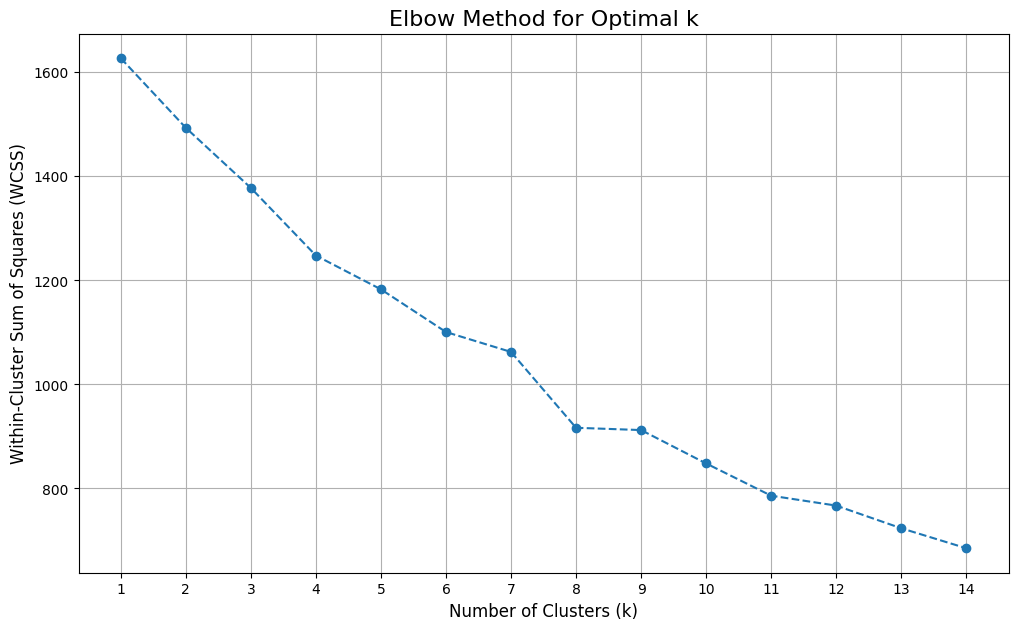

In [ ]:
# Use the Elbow Method to find the optimal k
wcss = []
k_range = range(1, 15) # Check a wider range of clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(features_df)
    wcss.append(kmeans.inertia_)

# Plot the graph
plt.figure(figsize=(12, 7))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()


Cluster Profiles for k=6:
         delirium  dementia  schizophrenia  schizophreniform  schizoaffective  \
CLUSTER                                                                         
0        1.998857  1.997714       1.975429          1.997143         1.997143   
1        2.000000  2.000000       2.000000          2.000000         2.000000   
2        2.000000  2.000000       1.991304          2.000000         2.000000   
3        2.000000  2.000000       1.992806          1.992806         1.992806   
4        2.000000  2.000000       1.971429          1.990476         1.990476   
5        2.000000  2.000000       2.000000          2.000000         2.000000   

         delusional  briepsych  substpsych  psychnotspe  mayordepres  ...  \
CLUSTER                                                               ...   
0          1.990286   1.996000    1.969143     1.994286     1.952571  ...   
1          2.000000   2.000000    1.971429     2.000000     1.992857  ...   
2          1.991

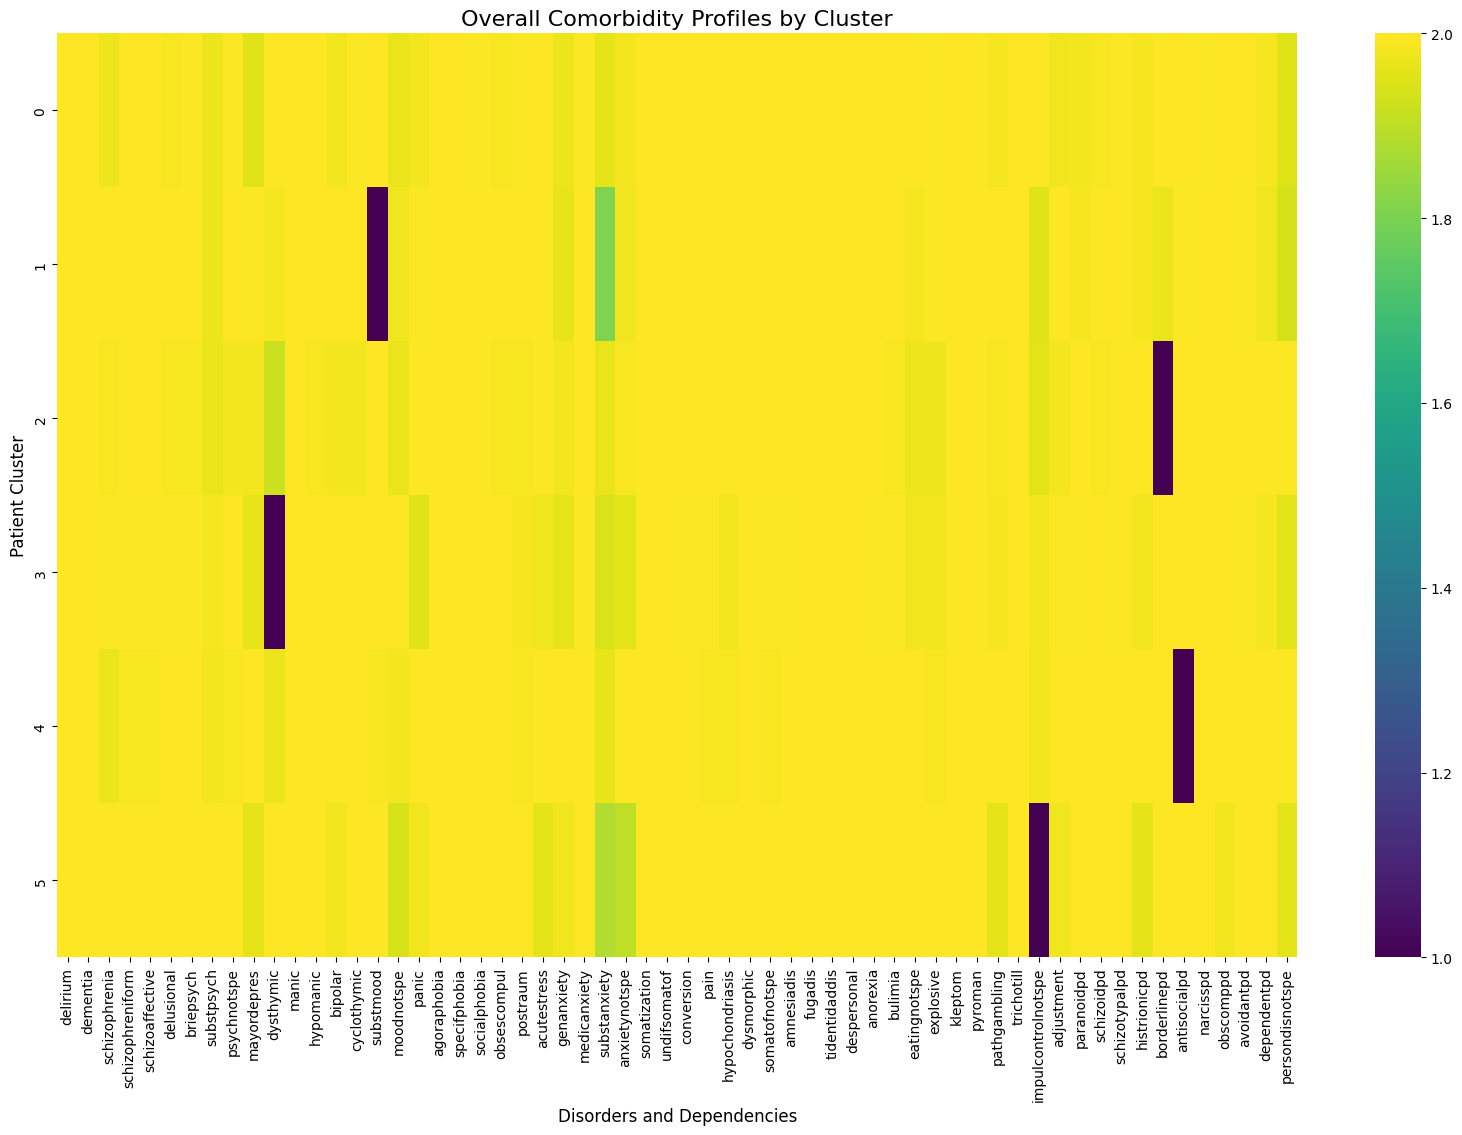

In [ ]:
# Set the optimal k from your elbow plot
optimal_k = 6 # <--- CHANGE THIS VALUE BASED ON YOUR PLOT

# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_df)

# Add the cluster labels to our analysis DataFrames
analysis_df['CLUSTER'] = cluster_labels
features_df['CLUSTER'] = cluster_labels

# --- Analyze and Visualize the Cluster Profiles ---
profile_analysis = features_df.groupby('CLUSTER').mean()

print(f"\nCluster Profiles for k={optimal_k}:")
print(profile_analysis)

# Visualize with a heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(profile_analysis, annot=False, cmap='viridis') # annot=False for better readability with many features
plt.title('Overall Comorbidity Profiles by Cluster', fontsize=16)
plt.xlabel('Disorders and Dependencies', fontsize=12)
plt.ylabel('Patient Cluster', fontsize=12)
plt.show()


Gender Distribution per Cluster:
sex_label    Female      Male
CLUSTER                      
0          0.178286  0.821714
1          0.357143  0.642857
2          0.434783  0.565217
3          0.302158  0.697842
4          0.095238  0.904762
5          0.039216  0.960784


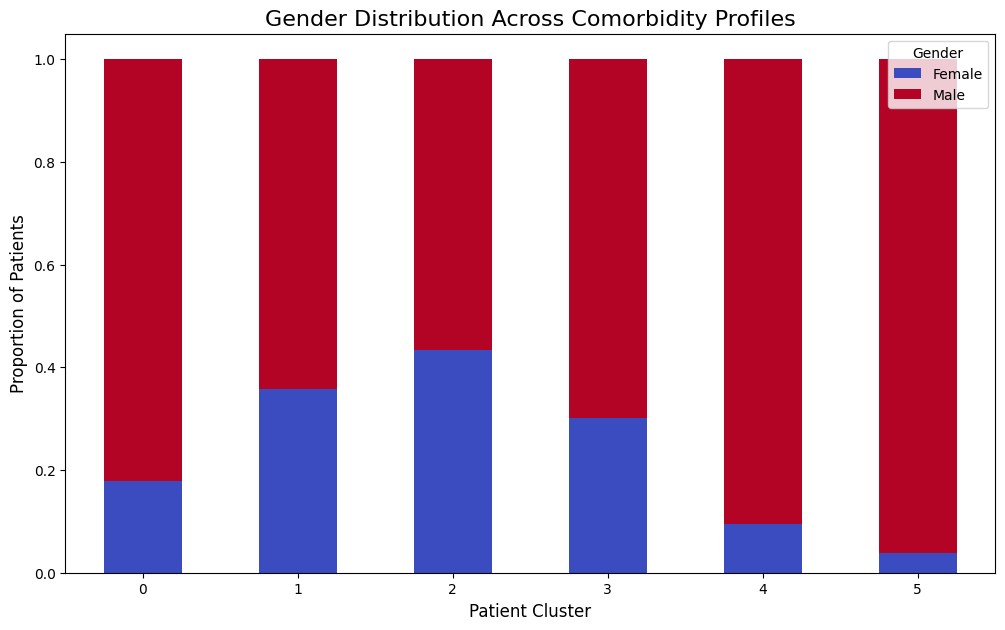

In [ ]:
# Map numerical 'sex' values to labels for clarity. Adjust if your mapping is different.
# If 'sex' is already text ('Male', 'Female'), you can skip this line.
analysis_df['sex_label'] = analysis_df['sex'].map({1: 'Male', 2: 'Female'})

# Analyze the gender distribution within each cluster
gender_dist = analysis_df.groupby('CLUSTER')['sex_label'].value_counts(normalize=True).unstack().fillna(0)
print("\nGender Distribution per Cluster:")
print(gender_dist)

# Visualize
gender_dist.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='coolwarm')
plt.title('Gender Distribution Across Comorbidity Profiles', fontsize=16)
plt.ylabel('Proportion of Patients', fontsize=12)
plt.xlabel('Patient Cluster', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.show()


Age Group Distribution per Cluster:
age_group  Young Adult (18-30)  Middle-Aged (31-45)  Older Adult (46-60)  \
CLUSTER                                                                    
0                     0.121143             0.504000             0.320000   
1                     0.078571             0.450000             0.385714   
2                     0.208696             0.652174             0.139130   
3                     0.079137             0.460432             0.366906   
4                     0.152381             0.676190             0.152381   
5                     0.313725             0.529412             0.137255   

age_group  Senior (61+)  
CLUSTER                  
0              0.054857  
1              0.085714  
2              0.000000  
3              0.093525  
4              0.019048  
5              0.019608  


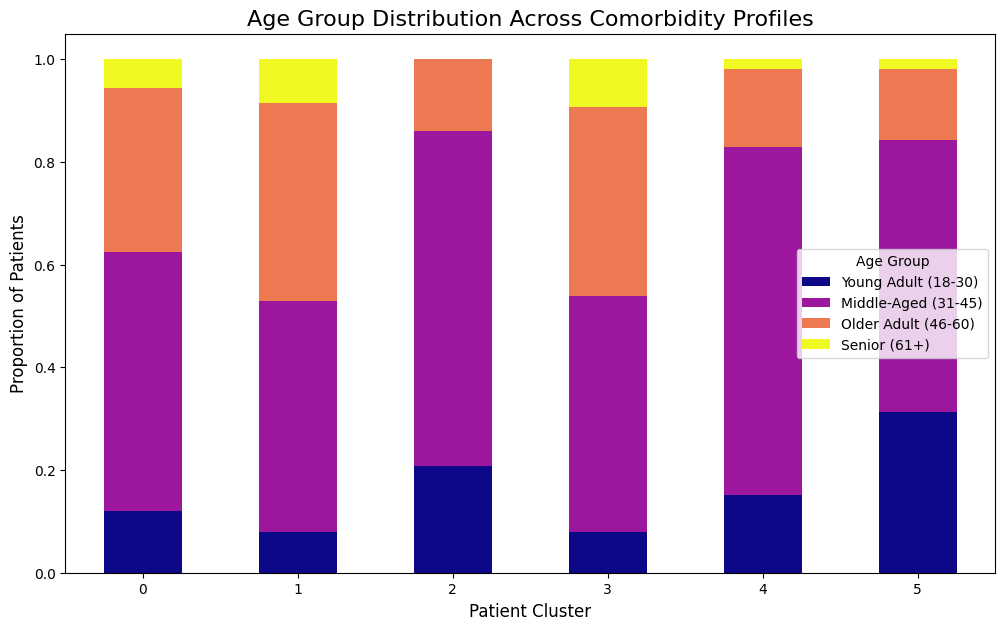

In [ ]:
# Analyze the age group distribution within each cluster
age_dist = analysis_df.groupby('CLUSTER')['age_group'].value_counts(normalize=True).unstack().fillna(0)
print("\nAge Group Distribution per Cluster:")
print(age_dist)

# Visualize
age_dist.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='plasma')
plt.title('Age Group Distribution Across Comorbidity Profiles', fontsize=16)
plt.ylabel('Proportion of Patients', fontsize=12)
plt.xlabel('Patient Cluster', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Age Group')
plt.show()


Clusters Ranked by Risk (Comorbidity Score):
         delirium  dementia  schizophrenia  schizophreniform  schizoaffective  \
CLUSTER                                                                         
0        1.998857  1.997714       1.975429          1.997143         1.997143   
4        2.000000  2.000000       1.971429          1.990476         1.990476   
2        2.000000  2.000000       1.991304          2.000000         2.000000   
1        2.000000  2.000000       2.000000          2.000000         2.000000   
3        2.000000  2.000000       1.992806          1.992806         1.992806   
5        2.000000  2.000000       2.000000          2.000000         2.000000   

         delusional  briepsych  substpsych  psychnotspe  mayordepres  ...  \
CLUSTER                                                               ...   
0          1.990286   1.996000    1.969143     1.994286     1.952571  ...   
4          2.000000   2.000000    1.980952     1.990476     2.000000  ... 

/tmp/ipython-input-3207956290.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_conditions[highest_risk_cluster_id], y=top_10_conditions.index, palette='Reds_r')


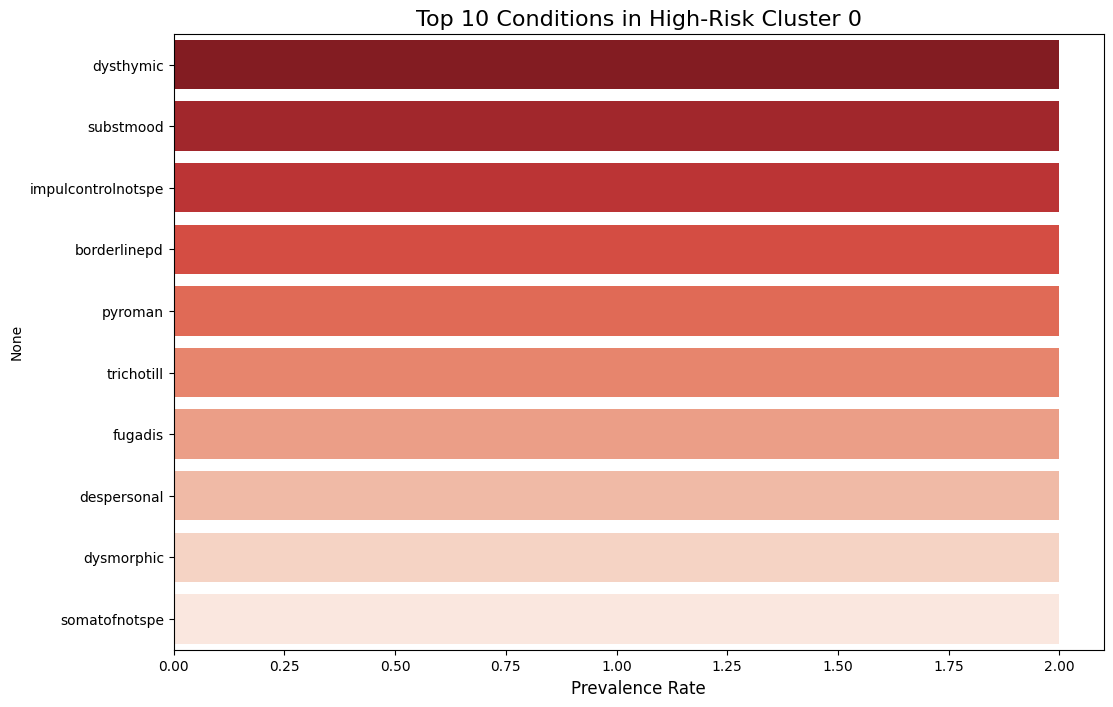


Demographics of the High-Risk Group:
Gender Distribution:
 sex_label
Male      0.821714
Female    0.178286
Name: proportion, dtype: float64

Age Distribution:
 age_group
Middle-Aged (31-45)    0.504000
Older Adult (46-60)    0.320000
Young Adult (18-30)    0.121143
Senior (61+)           0.054857
Name: proportion, dtype: float64


In [ ]:
# Calculate a 'Comorbidity Score' for each cluster (average number of diagnoses)
# profile_analysis['COMORBIDITY_SCORE'] = profile_analysis.sum(axis=1) # This line is no longer needed as the column exists

# Sort the clusters by this score
high_risk_clusters = profile_analysis.sort_values(by='COMORBIDITY_SCORE', ascending=False)

print("\nClusters Ranked by Risk (Comorbidity Score):")
print(high_risk_clusters)

# --- Focus on the #1 Highest-Risk Cluster ---
highest_risk_cluster_id = high_risk_clusters.index[0]
population_size = analysis_df['CLUSTER'].value_counts().loc[highest_risk_cluster_id]
total_population = len(analysis_df)
risk_percentage = (population_size / total_population) * 100

print(f"\n--- In-Depth Analysis of High-Risk Population (Cluster {highest_risk_cluster_id}) ---")
print(f"This group contains {population_size} patients ({risk_percentage:.2f}% of the total).")

# Get the top 10 most prevalent conditions in this high-risk group
high_risk_profile = high_risk_clusters.head(1).drop(columns='COMORBIDITY_SCORE').T
top_10_conditions = high_risk_profile.sort_values(by=highest_risk_cluster_id, ascending=False).head(10)

print("\nTop 10 Most Common Conditions in High-Risk Group:")
print(top_10_conditions)

# Visualize the top conditions
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_conditions[highest_risk_cluster_id], y=top_10_conditions.index, palette='Reds_r')
plt.title(f'Top 10 Conditions in High-Risk Cluster {highest_risk_cluster_id}', fontsize=16)
plt.xlabel('Prevalence Rate', fontsize=12)
plt.show()

# Get demographics of this group
high_risk_demographics_gender = analysis_df[analysis_df['CLUSTER'] == highest_risk_cluster_id]['sex_label'].value_counts(normalize=True)
high_risk_demographics_age = analysis_df[analysis_df['CLUSTER'] == highest_risk_cluster_id]['age_group'].value_counts(normalize=True)

print("\nDemographics of the High-Risk Group:")
print("Gender Distribution:\n", high_risk_demographics_gender)
print("\nAge Distribution:\n", high_risk_demographics_age)

In [ ]:
analysis_df['CLUSTER'].value_counts()

,count
CLUSTER,
0,1750
1,140
3,139
2,115
4,105
5,51


In [ ]:
# --- Step 1: Create a mapping for the 'primdrug' column ---

# IMPORTANT: You MUST verify this map with your dataset's documentation.
# These numbers are an educated guess.
drug_map = {
    1: 'Alcohol',
    2: 'Opiates (Heroin, etc.)',
    3: 'Cocaine',
    4: 'Cannabis',
    5: 'Hallucinogens',
    6: 'Benzodiazepines',
    # Add other mappings if you know them
}

# Create a new column with the readable drug names.
# .map() will apply the dictionary. .fillna() will label any unmapped codes as 'Other'.
df['primary_drug_label'] = df['primdrug'].map(drug_map).fillna('Other/Unknown')

print("Primary drug codes mapped to labels. Here is a count of each:")
print(df['primary_drug_label'].value_counts())

Primary drug codes mapped to labels. Here is a count of each:
primary_drug_label
Cannabis                  978
Alcohol                   805
Cocaine                   300
Other/Unknown             112
Opiates (Heroin, etc.)     66
Benzodiazepines            39
Name: count, dtype: int64


In [ ]:
# --- Step 2: Calculate the mean prevalence of each disorder for each drug group ---

# First, we need our list of diagnosis columns again
feature_columns = [
    'delirium', 'dementia', 'schizophrenia', 'schizophreniform', 'schizoaffective', 'delusional',
    'briepsych', 'substpsych', 'psychnotspe', 'mayordepres', 'dysthymic', 'manic', 'hypomanic',
    'bipolar', 'cyclothymic', 'substmood', 'moodnotspe', 'panic', 'agoraphobia', 'specifphobia',
    'socialphobia', 'obsescompul', 'postraum', 'acutestress', 'genanxiety', 'medicanxiety',
    'substanxiety', 'anxietynotspe', 'somatization', 'undifsomatof', 'conversion', 'pain',
    'hypochondriasis', 'dysmorphic', 'somatofnotspe', 'amnesiadis', 'fugadis', 'tidentidaddis',
    'despersonal', 'anorexia', 'bulimia', 'eatingnotspe', 'explosive', 'kleptom', 'pyroman',
    'pathgambling', 'trichotill', 'impulcontrolnotspe', 'adjustment', 'paranoidpd', 'schizoidpd',
    'schizotypalpd', 'histrionicpd', 'borderlinepd', 'antisocialpd', 'narcisspd', 'obscomppd',
    'avoidantpd', 'dependentpd', 'persondisnotspe'
]

# Create a new DataFrame for this analysis
drug_analysis_df = df[['primary_drug_label'] + feature_columns]

# Group by the primary drug and calculate the mean
drug_comorbidity_rates = drug_analysis_df.groupby('primary_drug_label').mean()

# Remember your data uses 1 for absent, 2 for present. We can normalize this to 0 and 1.
# A value of 2 becomes 1 (100% prevalence), and 1 becomes 0 (0% prevalence).
drug_comorbidity_rates_normalized = drug_comorbidity_rates - 1

print("\nComorbidity rates calculated per primary drug (normalized to 0-1 scale):")
drug_comorbidity_rates_normalized.head()


Comorbidity rates calculated per primary drug (normalized to 0-1 scale):


,delirium,dementia,schizophrenia,schizophreniform,schizoaffective,delusional,briepsych,substpsych,psychnotspe,mayordepres,...,schizoidpd,schizotypalpd,histrionicpd,borderlinepd,antisocialpd,narcisspd,obscomppd,avoidantpd,dependentpd,persondisnotspe
primary_drug_label,,,,,,,,,,,,,,,,,,,,,
Alcohol,1.000000,1.00000,0.971429,0.997516,0.998758,0.992547,0.996273,0.972671,0.993789,0.968944,...,0.991304,0.995031,0.985093,0.929193,0.908075,0.992547,0.996273,0.993789,0.992547,0.972671
Benzodiazepines,1.000000,1.00000,0.974359,1.000000,0.974359,1.000000,1.000000,1.000000,0.974359,1.000000,...,1.000000,1.000000,1.000000,0.974359,1.000000,1.000000,1.000000,1.000000,1.000000,0.923077
Cannabis,0.998978,0.99591,0.988753,1.000000,0.997955,0.989775,0.997955,0.981595,0.995910,0.949898,...,0.993865,1.000000,0.979550,0.967280,0.983640,0.996933,0.997955,0.998978,0.985685,0.949898
Cocaine,0.996667,1.00000,0.980000,0.996667,0.990000,0.996667,0.986667,0.930000,0.996667,0.956667,...,0.996667,0.993333,1.000000,0.930000,0.980000,0.996667,0.996667,0.996667,0.986667,0.963333
"Opiates (Heroin, etc.)",1.000000,1.00000,0.954545,0.969697,1.000000,0.984848,1.000000,0.954545,0.984848,0.969697,...,0.969697,0.984848,1.000000,0.954545,0.969697,0.984848,1.000000,1.000000,0.984848,0.954545


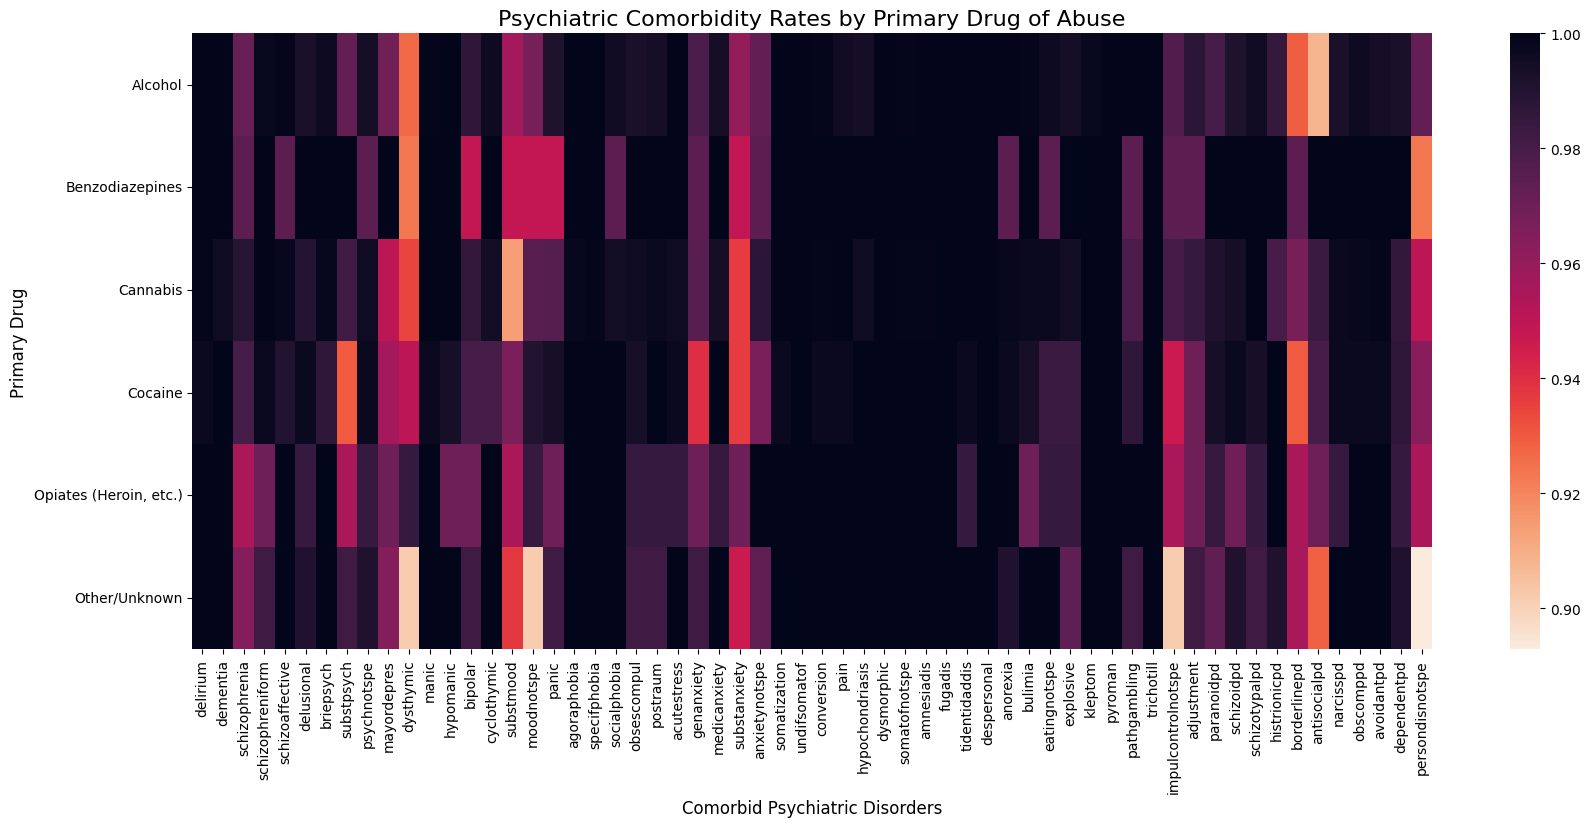

In [ ]:
# --- Step 3: Visualize the results with a heatmap ---

plt.figure(figsize=(20, 8)) # Make the figure wide to fit all the disorder names
sns.heatmap(
    drug_comorbidity_rates_normalized,
    cmap='rocket_r', # A good colormap for this (dark = low, bright = high)
    annot=False, # Set to True if you have few drugs/disorders, otherwise it's too cluttered
    fmt='.2f'
)

plt.title('Psychiatric Comorbidity Rates by Primary Drug of Abuse', fontsize=16)
plt.xlabel('Comorbid Psychiatric Disorders', fontsize=12)
plt.ylabel('Primary Drug', fontsize=12)
plt.show()

/tmp/ipython-input-3974441553.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cocaine_profile.values, y=cocaine_profile.index, palette='Reds_r')


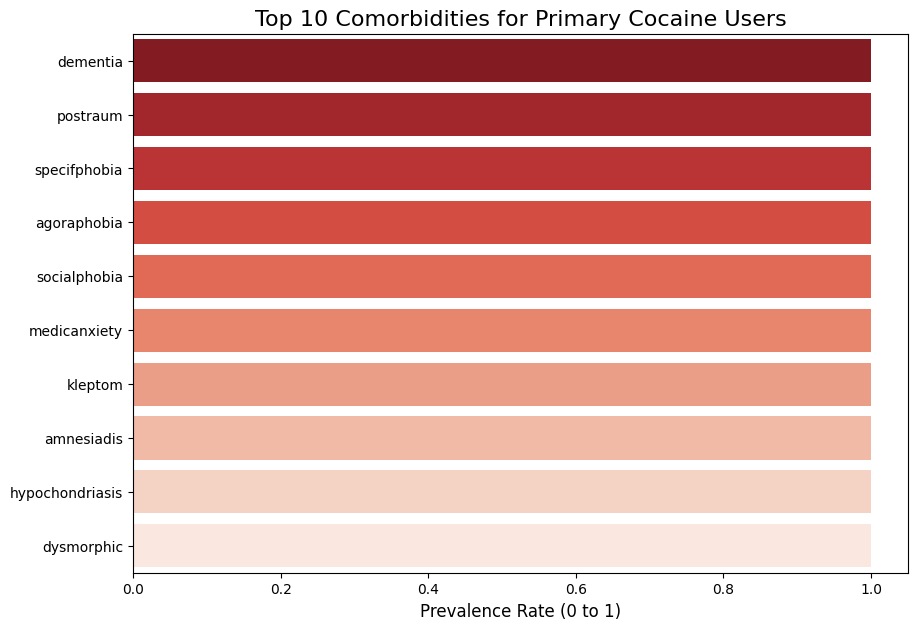

/tmp/ipython-input-3974441553.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=alcohol_profile.values, y=alcohol_profile.index, palette='Blues_r')


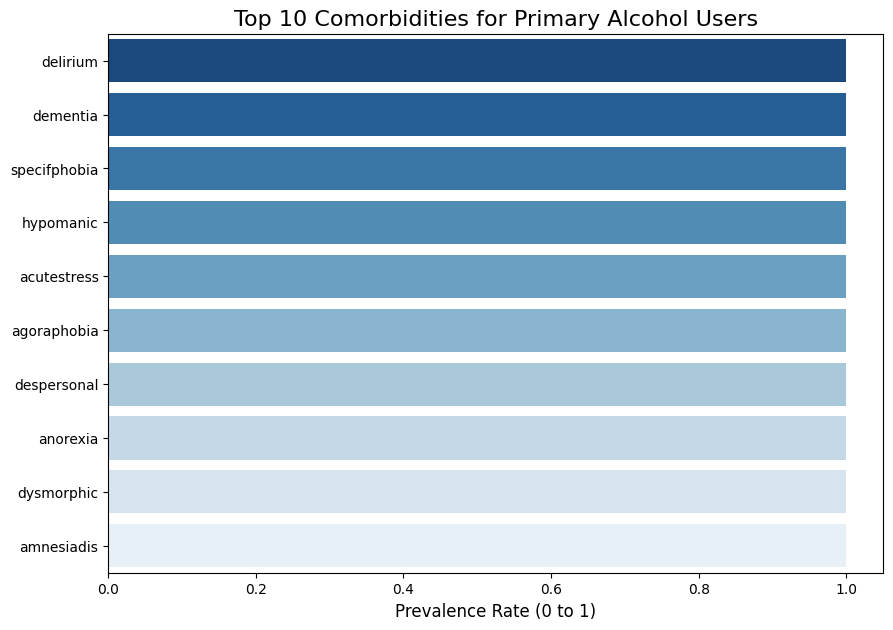

In [ ]:
# --- Step 4 (Optional): Create bar charts for specific drugs ---

# Let's analyze the top 10 comorbidities for the 'Cocaine' group
try:
    cocaine_profile = drug_comorbidity_rates_normalized.loc['Cocaine'].sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 7))
    sns.barplot(x=cocaine_profile.values, y=cocaine_profile.index, palette='Reds_r')
    plt.title('Top 10 Comorbidities for Primary Cocaine Users', fontsize=16)
    plt.xlabel('Prevalence Rate (0 to 1)', fontsize=12)
    plt.ylabel('')
    plt.show()

except KeyError:
    print("Could not generate Cocaine chart. Check if 'Cocaine' is a label in your data.")


# Let's do the same for the 'Alcohol' group
try:
    alcohol_profile = drug_comorbidity_rates_normalized.loc['Alcohol'].sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 7))
    sns.barplot(x=alcohol_profile.values, y=alcohol_profile.index, palette='Blues_r')
    plt.title('Top 10 Comorbidities for Primary Alcohol Users', fontsize=16)
    plt.xlabel('Prevalence Rate (0 to 1)', fontsize=12)
    plt.ylabel('')
    plt.show()

except KeyError:
    print("Could not generate Alcohol chart. Check if 'Alcohol' is a label in your data.")

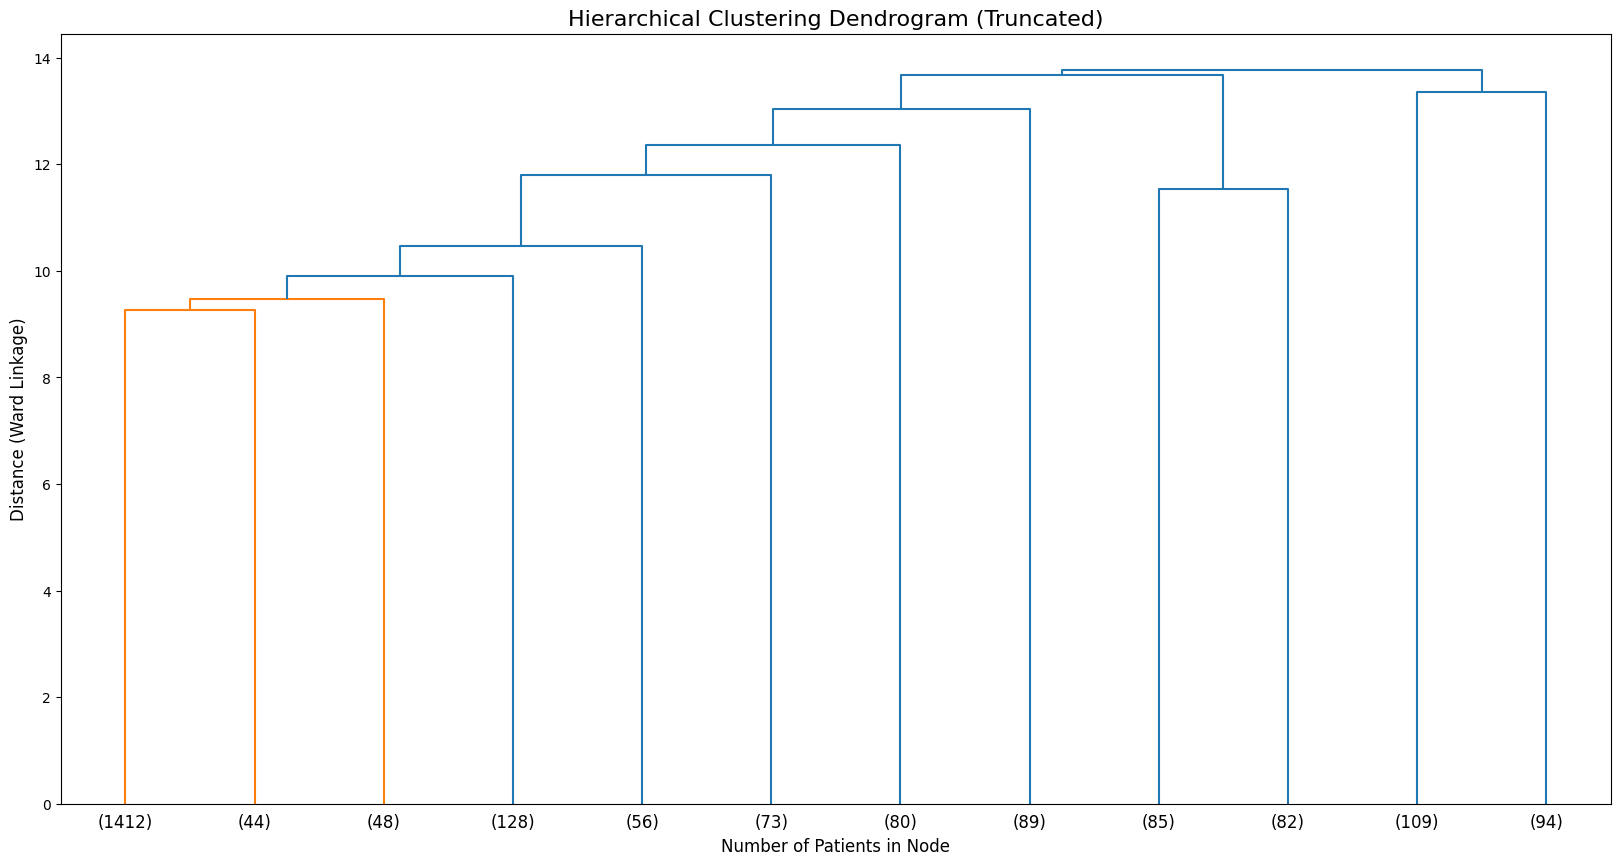

In [ ]:
# Import the necessary library for hierarchical clustering
import scipy.cluster.hierarchy as sch

# --- Generate the linkage matrix using Ward's method ---
# We use the same 'features_df' from before, but without the old cluster labels.
features_for_hc = features_df.drop(columns=['CLUSTER', 'HIERARCHICAL_CLUSTER'], errors='ignore')
linked = sch.linkage(features_for_hc, method='ward')


# --- Plot the dendrogram ---
# A dendrogram for 2300 patients would be unreadable, so we'll truncate it
# to show the final, most important cluster merges.
plt.figure(figsize=(20, 10))
sch.dendrogram(linked,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=True,
               truncate_mode='lastp',  # Show only the last 'p' merged clusters
               p=12)                  # We will show the last 12 merges

plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=16)
plt.xlabel('Number of Patients in Node', fontsize=12)
plt.ylabel('Distance (Ward Linkage)', fontsize=12)
plt.show()


Profiles found using Hierarchical Clustering (Normalized):
                      delirium  dementia  schizophrenia  schizophreniform  \
HIERARCHICAL_CLUSTER                                                        
0                       1.0000       1.0            1.0               1.0   
1                       1.0000       1.0            1.0               1.0   
2                       1.0000       1.0            1.0               1.0   
3                       1.0000       1.0            1.0               1.0   
4                       0.9875       1.0            1.0               1.0   

                      schizoaffective  delusional  briepsych  substpsych  \
HIERARCHICAL_CLUSTER                                                       
0                              1.0000      1.0000   1.000000    0.957447   
1                              1.0000      1.0000   1.000000    0.972477   
2                              1.0000      1.0000   0.994012    0.988024   
3                   

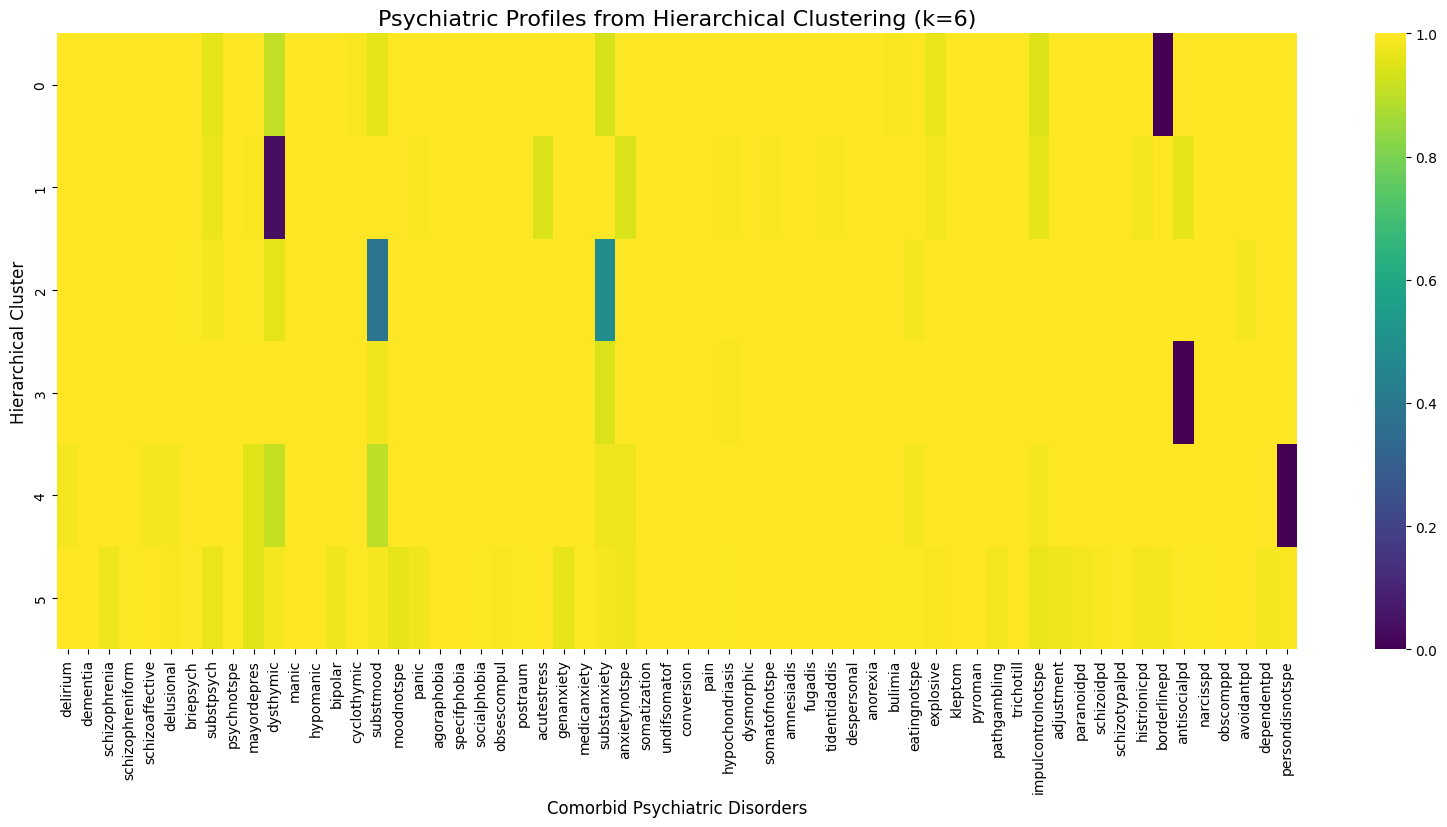

In [ ]:
from scipy.cluster.hierarchy import fcluster

# --- Form 6 clusters based on the linkage matrix ---
# We specify k=6 to make the results comparable to our K-Means analysis.
k = 6
# fcluster creates the cluster labels. They start from 1, so we subtract 1 to match K-Means (0-5).
hierarchical_labels = fcluster(linked, k, criterion='maxclust') - 1


# --- Add these new labels to our DataFrames for analysis ---
analysis_df['HIERARCHICAL_CLUSTER'] = hierarchical_labels
features_df['HIERARCHICAL_CLUSTER'] = hierarchical_labels


# --- Analyze the new profiles and create a heatmap ---
# We group by the new hierarchical cluster labels and calculate the means.
# Remember to normalize the data (subtract 1) so 0=absent and 1=present.
hierarchical_profiles = features_df.groupby('HIERARCHICAL_CLUSTER')[feature_columns].mean() - 1

print("\nProfiles found using Hierarchical Clustering (Normalized):")
print(hierarchical_profiles.head())


# --- Visualize the Hierarchical Clustering Profiles ---
plt.figure(figsize=(20, 8))
sns.heatmap(hierarchical_profiles,
            cmap='viridis',
            annot=False)

plt.title('Psychiatric Profiles from Hierarchical Clustering (k=6)', fontsize=16)
plt.xlabel('Comorbid Psychiatric Disorders', fontsize=12)
plt.ylabel('Hierarchical Cluster', fontsize=12)
plt.show()

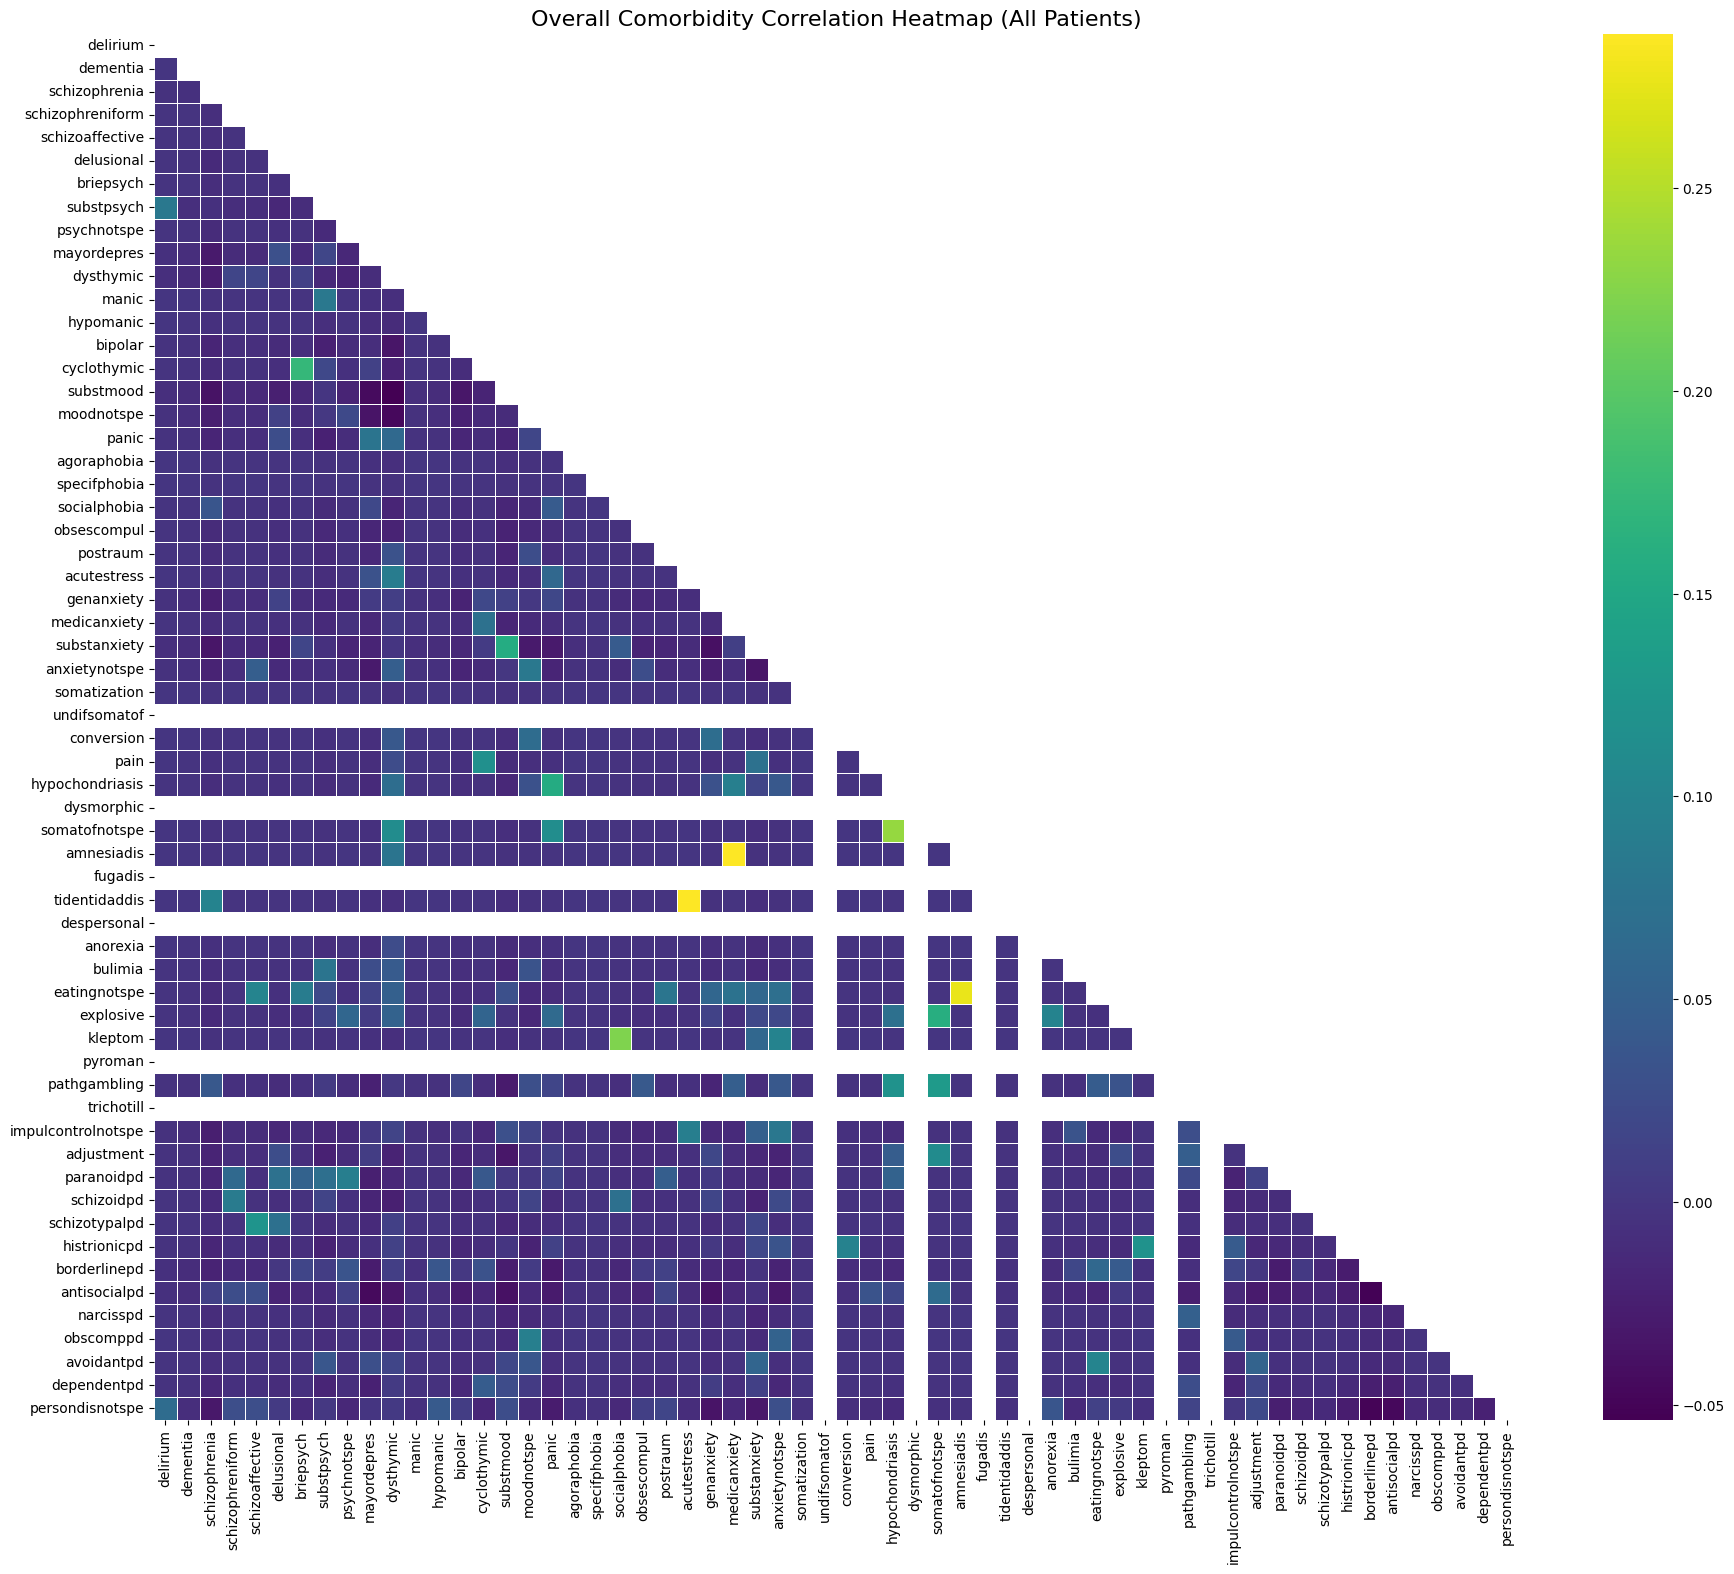

In [ ]:
# --- Step 1: Create a correlation matrix for all disorders ---

# We'll use the normalized features_df from our previous analysis (where 1=present, 0=absent).
# We need to drop the cluster labels if they are still there.
features_normalized = (features_df.drop(columns=['CLUSTER', 'HIERARCHICAL_CLUSTER'], errors='ignore') - 1)

# The .corr() method calculates the pairwise correlation between all columns.
comorbidity_matrix = features_normalized.corr()


# --- Visualize the matrix as a heatmap ---
# We'll mask the upper triangle since the matrix is symmetrical (corr(A,B) = corr(B,A))
mask = np.triu(np.ones_like(comorbidity_matrix, dtype=bool))

plt.figure(figsize=(22, 18))
sns.heatmap(comorbidity_matrix,
            mask=mask,
            cmap='viridis', # Use a different colormap for variety
            annot=False,   # Annotations would be too cluttered
            linewidths=.5)

plt.title('Overall Comorbidity Correlation Heatmap (All Patients)', fontsize=16)
plt.show()

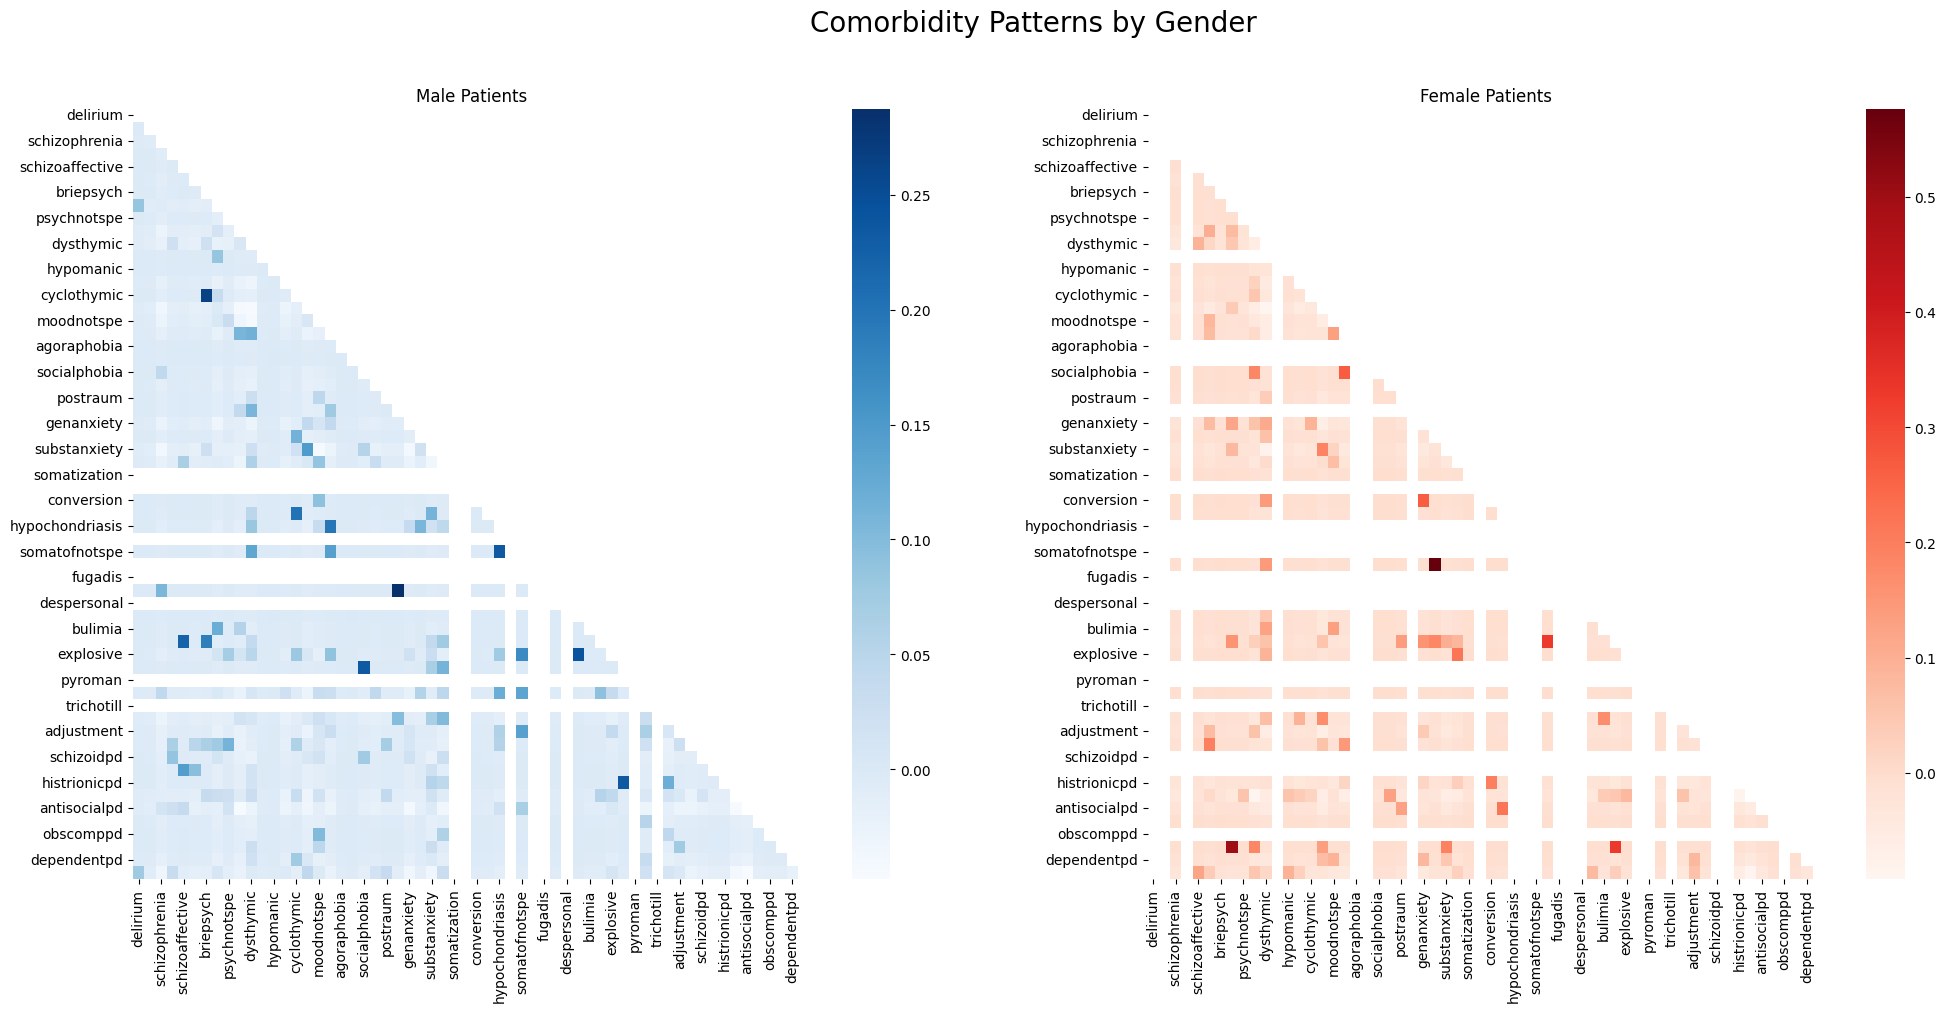

In [ ]:
# --- Step 2: Create separate heatmaps for Males and Females ---

# First, ensure your main 'df' has the readable sex_label from before
df['sex_label'] = df['sex'].map({1: 'Male', 2: 'Female'})

# Create a DataFrame with only the normalized features and the sex label
full_normalized_df = df.copy()
full_normalized_df[feature_columns] = full_normalized_df[feature_columns] - 1

# Filter for each gender
male_df = full_normalized_df[full_normalized_df['sex_label'] == 'Male']
female_df = full_normalized_df[full_normalized_df['sex_label'] == 'Female']

# Calculate correlation matrices for each gender
male_corr = male_df[feature_columns].corr()
female_corr = female_df[feature_columns].corr()

# Create subplots to show the heatmaps side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle('Comorbidity Patterns by Gender', fontsize=20)

# Male Heatmap
sns.heatmap(male_corr, ax=ax1, cmap='Blues', mask=np.triu(np.ones_like(male_corr, dtype=bool)))
ax1.set_title('Male Patients')

# Female Heatmap
sns.heatmap(female_corr, ax=ax2, cmap='Reds', mask=np.triu(np.ones_like(female_corr, dtype=bool)))
ax2.set_title('Female Patients')

plt.show()

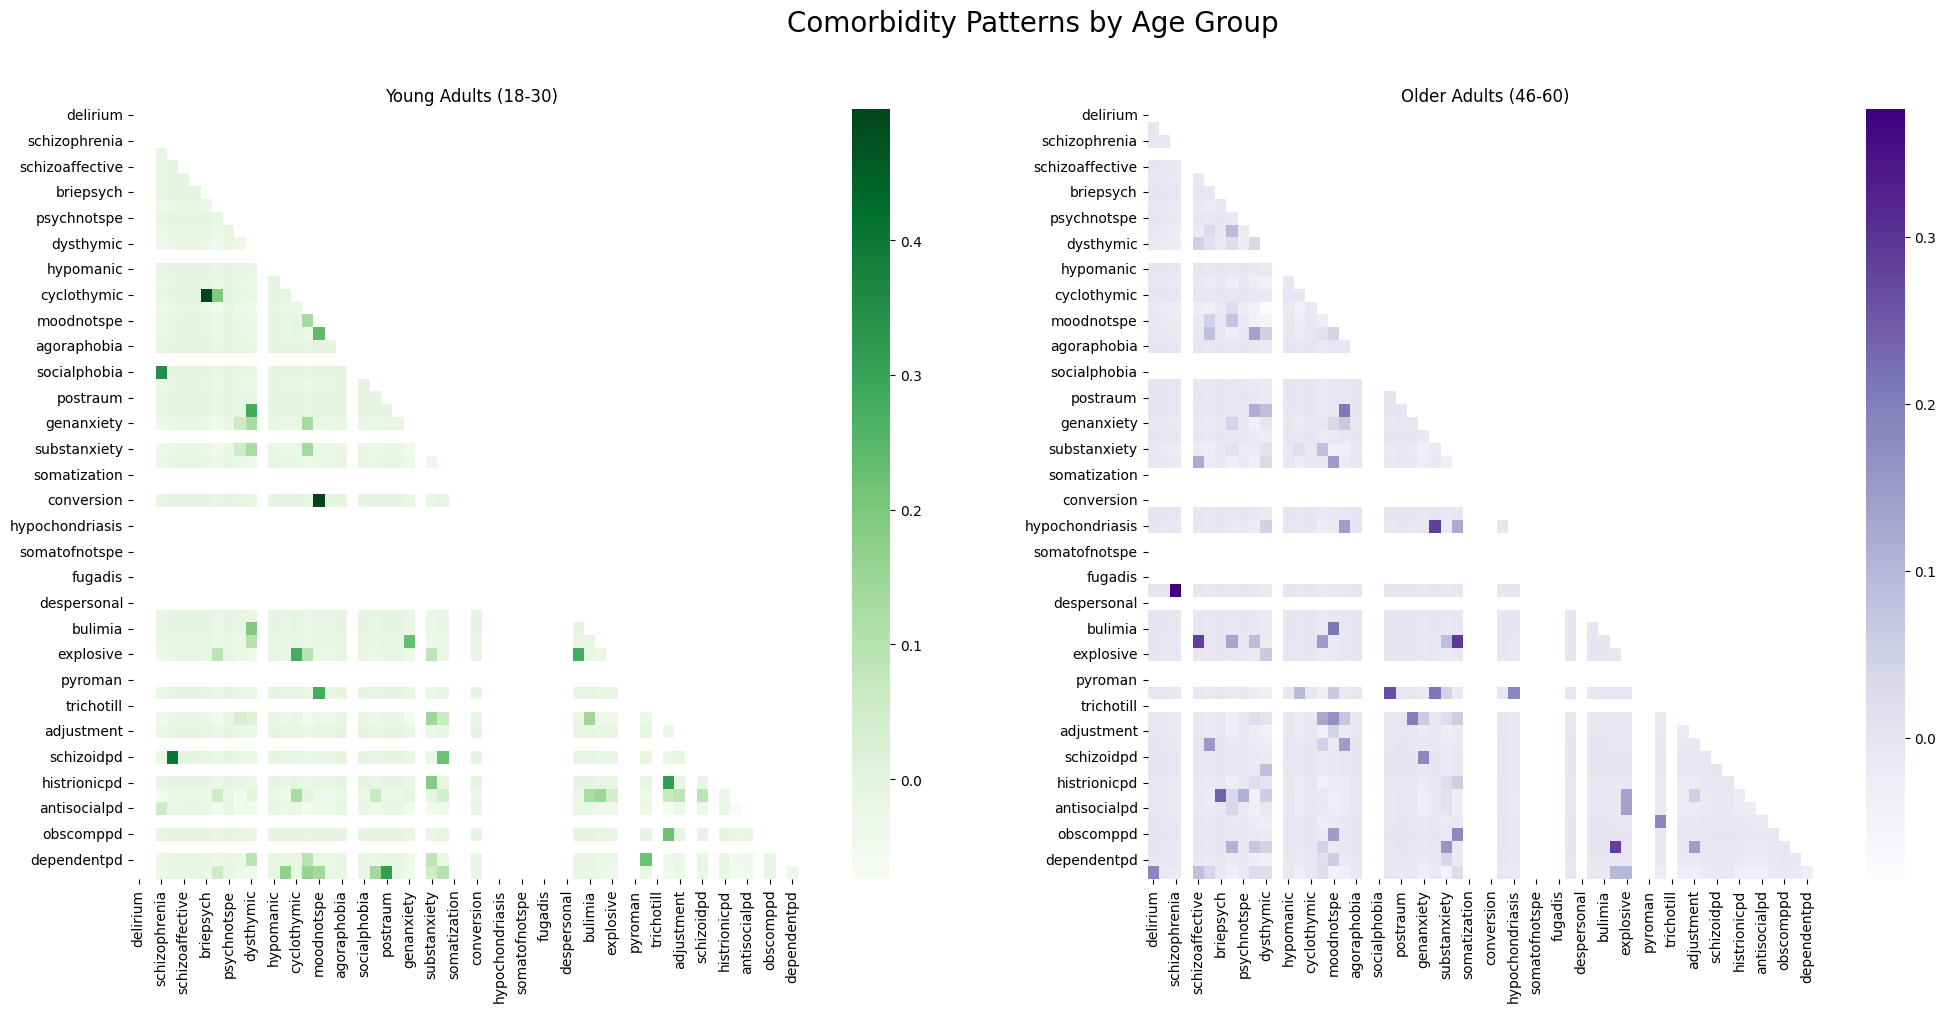

In [ ]:
# --- Step 3: Create separate heatmaps for different Age Groups ---

# Filter for each age group (using the 'age_group' column from earlier)
young_adult_df = full_normalized_df[full_normalized_df['age_group'] == 'Young Adult (18-30)']
older_adult_df = full_normalized_df[full_normalized_df['age_group'] == 'Older Adult (46-60)']

# Calculate correlation matrices for each age group
young_corr = young_adult_df[feature_columns].corr()
older_corr = older_adult_df[feature_columns].corr()

# Create subplots to show the heatmaps side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle('Comorbidity Patterns by Age Group', fontsize=20)

# Young Adult Heatmap
sns.heatmap(young_corr, ax=ax1, cmap='Greens', mask=np.triu(np.ones_like(young_corr, dtype=bool)))
ax1.set_title('Young Adults (18-30)')

# Older Adult Heatmap
sns.heatmap(older_corr, ax=ax2, cmap='Purples', mask=np.triu(np.ones_like(older_corr, dtype=bool)))
ax2.set_title('Older Adults (46-60)')

plt.show()

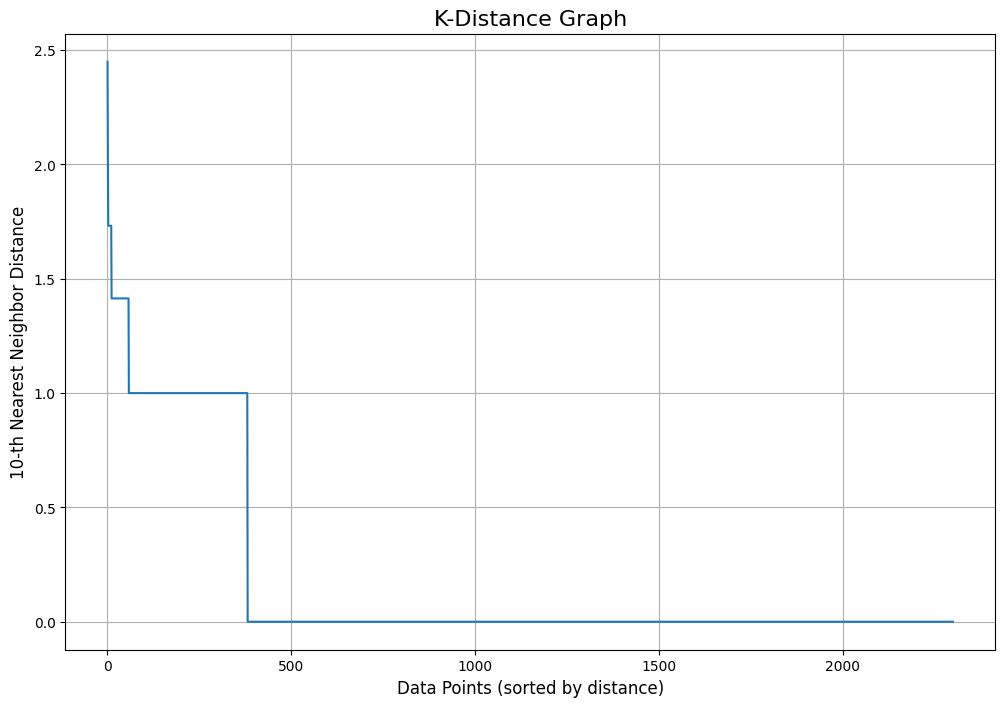

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# --- Step 1: Find the optimal eps value using a k-distance graph ---

# We'll use the same normalized features from the previous analyses.
features_normalized = (features_df.drop(columns=['CLUSTER', 'HIERARCHICAL_CLUSTER', 'DBSCAN_CLUSTER'], errors='ignore') - 1)

# Let's calculate the distance from each point to its 10 nearest neighbors.
# A good starting point for min_samples is often 2 * number of dimensions.
# Since you have many dimensions, we'll pick a slightly higher value like 10 for this calculation.
ns = 10
nbrs = NearestNeighbors(n_neighbors=ns).fit(features_normalized)
distances, indices = nbrs.kneighbors(features_normalized)

# Get the distance to the k-th neighbor (in this case, the 10th neighbor)
distanceDec = sorted(distances[:, ns-1], reverse=True)

# Plot the k-distance graph
plt.figure(figsize=(12, 8))
plt.plot(list(range(1, len(distanceDec) + 1)), distanceDec)
plt.title('K-Distance Graph', fontsize=16)
plt.xlabel('Data Points (sorted by distance)', fontsize=12)
plt.ylabel(f'{ns}-th Nearest Neighbor Distance', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

# --- Step 2: Apply DBSCAN with your chosen parameters ---

# IMPORTANT: Replace these values with your findings from the graph.
# Let's assume you found eps = 2.5 and will use min_samples = 10.
dbscan = DBSCAN(eps=2.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(features_normalized)


# --- Add the new labels to your analysis DataFrame ---
analysis_df['DBSCAN_CLUSTER'] = dbscan_labels


# --- Analyze the results ---
# The label '-1' represents noise/outliers.
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters_} clusters.")
print(f"It also identified {n_noise_} noise points (patients with rare patterns).")

print("\nPatient counts per cluster (-1 is noise):")
print(analysis_df['DBSCAN_CLUSTER'].value_counts())

DBSCAN found 1 clusters.
It also identified 0 noise points (patients with rare patterns).

Patient counts per cluster (-1 is noise):
DBSCAN_CLUSTER
0    2300
Name: count, dtype: int64



Profiles found using DBSCAN (Normalized):
                delirium  dementia  schizophrenia  schizophreniform  \
DBSCAN_CLUSTER                                                        
0                0.99913  0.998261        0.97913          0.996957   

                schizoaffective  delusional  briepsych  substpsych  \
DBSCAN_CLUSTER                                                       
0                      0.996957    0.991739   0.996087    0.971304   

                psychnotspe  mayordepres  ...  schizoidpd  schizotypalpd  \
DBSCAN_CLUSTER                            ...                              
0                  0.994348     0.959565  ...    0.992609       0.996087   

                histrionicpd  borderlinepd  antisocialpd  narcisspd  \
DBSCAN_CLUSTER                                                        
0                   0.985652      0.948261      0.953913   0.995217   

                obscomppd  avoidantpd  dependentpd  persondisnotspe  
DBSCAN_CLUSTER     

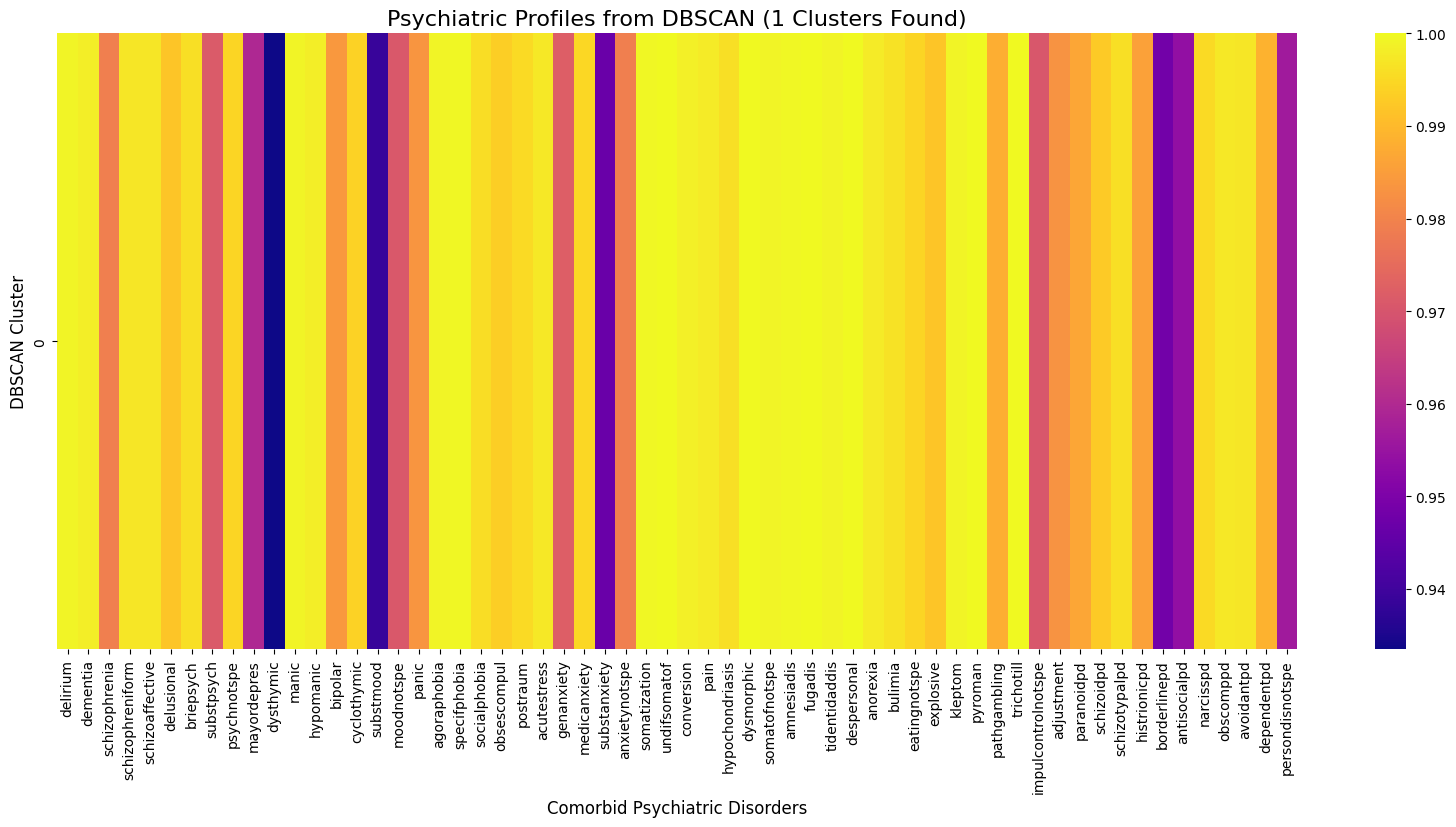

In [ ]:
# --- Step 3: Visualize the profiles of the clusters (excluding noise) ---

# Add the labels to the features DataFrame for analysis
features_df['DBSCAN_CLUSTER'] = dbscan_labels

# Filter out the noise points for the heatmap
clusters_only_df = features_df[features_df['DBSCAN_CLUSTER'] != -1]

# Group by the DBSCAN cluster labels and calculate the means (and normalize)
dbscan_profiles = (clusters_only_df.groupby('DBSCAN_CLUSTER')[feature_columns].mean() - 1)

print("\nProfiles found using DBSCAN (Normalized):")
print(dbscan_profiles)


# --- Visualize the DBSCAN Profiles ---
if n_clusters_ > 0:
    plt.figure(figsize=(20, 8))
    sns.heatmap(dbscan_profiles,
                cmap='plasma',
                annot=False)

    plt.title(f'Psychiatric Profiles from DBSCAN ({n_clusters_} Clusters Found)', fontsize=16)
    plt.xlabel('Comorbid Psychiatric Disorders', fontsize=12)
    plt.ylabel('DBSCAN Cluster', fontsize=12)
    plt.show()
else:
    print("\nNo dense clusters were found with the current parameters.")

***Can we build a machine learning model to accurately predict whether a patient is at "High Risk" for severe comorbidity based on their diagnoses?***

In [ ]:
# Import necessary libraries for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

# You might need to re-upload your .zip file if the session is new
from google.colab import files
uploaded = files.upload()

# Get the name of the uploaded zip file and extract the CSV
zip_file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    csv_file_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    print(f"Extracting and loading: {csv_file_name}")
    with z.open(csv_file_name) as f:
        # Read the CSV with semicolon separator
        df = pd.read_csv(f, sep=';')

print("\nDataset loaded successfully into the 'df' DataFrame!")

Saving archive (1).zip to archive (1).zip
Extracting and loading: 2012BASECOPSIAD ingles (2).csv

Dataset loaded successfully into the 'df' DataFrame!


In [ ]:
## COMPLETE STEP 1 & 2: DATA PREP AND MODEL TRAINING ##

# First, make sure you have the libraries installed
!pip install -q xgboost shap

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# --- Part 1: Define Features and Create the 'High Risk' Target ---

# Clean all column names in the DataFrame
df.columns = df.columns.str.strip().str.lower().str.replace('[^a-zA-Z0-9_]', '', regex=True)

# Define the list of feature columns
feature_columns = [
    'delirium', 'dementia', 'schizophrenia', 'schizophreniform', 'schizoaffective', 'delusional',
    'briepsych', 'substpsych', 'psychnotspe', 'mayordepres', 'dysthymic', 'manic', 'hypomanic',
    'bipolar', 'cyclothymic', 'substmood', 'moodnotspe', 'panic', 'agoraphobia', 'specifphobia',
    'socialphobia', 'obsescompul', 'postraum', 'acutestress', 'genanxiety', 'medicanxiety',
    'substanxiety', 'anxietynotspe', 'somatization', 'undifsomatof', 'conversion', 'pain',
    'hypochondriasis', 'dysmorphic', 'somatofnotspe', 'amnesiadis', 'fugadis', 'tidentidaddis',
    'despersonal', 'anorexia', 'bulimia', 'eatingnotspe', 'explosive', 'kleptom', 'pyroman',
    'pathgambling', 'trichotill', 'impulcontrolnotspe', 'adjustment', 'paranoidpd', 'schizoidpd',
    'schizotypalpd', 'histrionicpd', 'borderlinepd', 'antisocialpd', 'narcisspd', 'obscomppd',
    'avoidantpd', 'dependentpd', 'persondisnotspe'
]

# Create the features_df DataFrame. Assumes original data uses 1 for absent, 2 for present.
features_df = df[feature_columns].fillna(1)

# Normalize to 0 (absent) and 1 (present) for the model
features_normalized = features_df - 1

# Calculate the total number of disorders for each patient
df['comorbidity_count'] = features_normalized.sum(axis=1)

# Define "High Risk" based on the 75th percentile of the comorbidity count
threshold = df['comorbidity_count'].quantile(0.75)
df['is_high_risk'] = (df['comorbidity_count'] >= threshold).astype(int)

print(f"Defining 'High Risk' as having {threshold} or more disorders.")
print("Distribution of risk groups:")
print(df['is_high_risk'].value_counts())

# Our features (X) and target (y) are now defined
X = features_normalized
y = df['is_high_risk']
print("\n✅ Features (X) and target (y) created successfully.")


# --- Part 2: Split Data and Train the XGBoost Model ---

# Split data into 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

print("\n✅ XGBoost model trained successfully.")

Defining 'High Risk' as having 59.0 or more disorders.
Distribution of risk groups:
is_high_risk
1    1977
0     323
Name: count, dtype: int64

✅ Features (X) and target (y) created successfully.

✅ XGBoost model trained successfully.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:47:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Model Evaluation ---

✅ Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      0.82      0.90        65
   High Risk       0.97      1.00      0.99       395

    accuracy                           0.97       460
   macro avg       0.99      0.91      0.94       460
weighted avg       0.97      0.97      0.97       460


✅ Confusion Matrix:


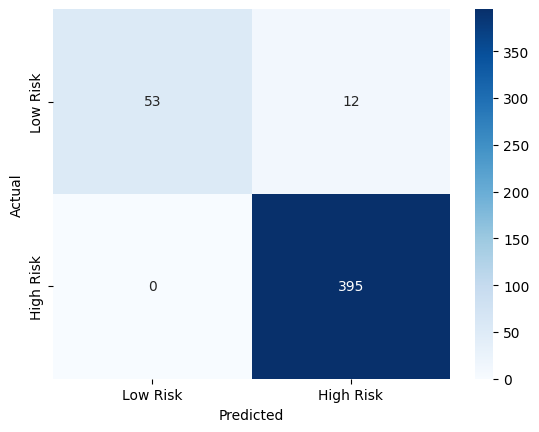

In [ ]:
## STEP 3: EVALUATE THE MODEL ##

from sklearn.metrics import classification_report, confusion_matrix

# Use the trained model to make predictions on the test data
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print("\n✅ Classification Report:")
# This report shows you precision, recall, and f1-score.
# Precision: Of all the patients we predicted as 'High Risk', how many actually were?
# Recall: Of all the actual 'High Risk' patients, how many did we find?
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

print("\n✅ Confusion Matrix:")
# This visual shows the exact number of correct and incorrect predictions.
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


--- SHAP Feature Importance Analysis ---

✅ This plot shows the most important features for predicting high-risk status.


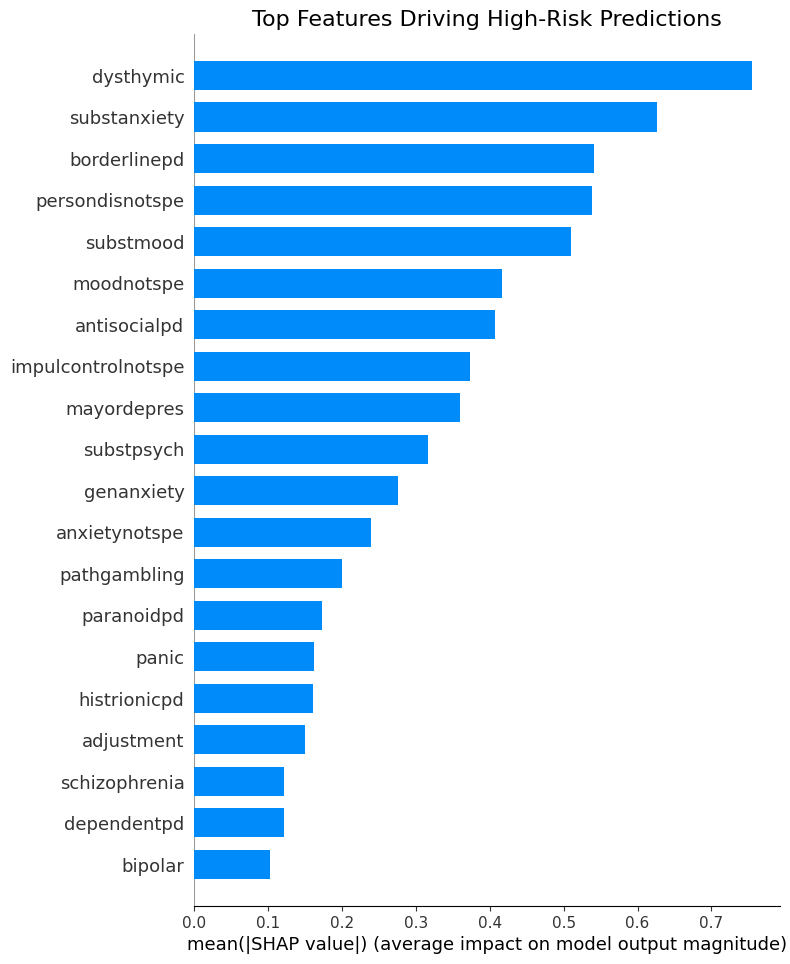


✅ This plot shows how the value of each feature impacts the prediction.


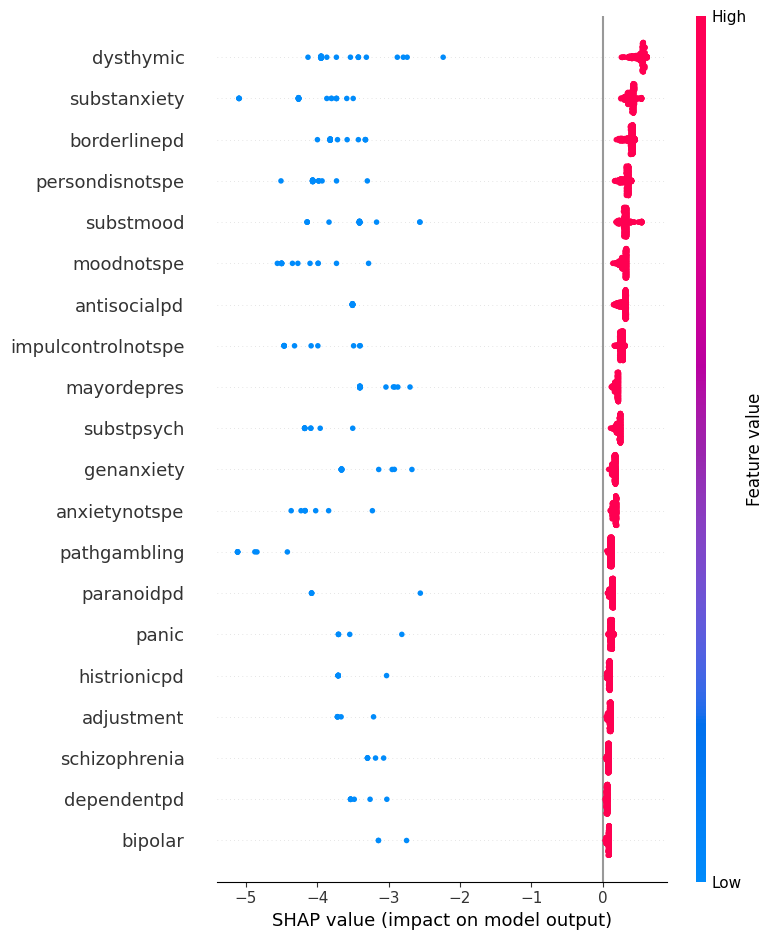

In [ ]:
## STEP 4: EXPLAIN THE MODEL WITH SHAP ##

import shap

# Create a SHAP explainer to analyze the model
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# --- Create the SHAP summary plots ---
print("\n--- SHAP Feature Importance Analysis ---")
print("\n✅ This plot shows the most important features for predicting high-risk status.")
# This first plot shows the overall importance of each feature.
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Features Driving High-Risk Predictions", fontsize=16)
plt.show()

print("\n✅ This plot shows how the value of each feature impacts the prediction.")
# This second, more detailed plot shows whether the presence (red) or absence (blue)
# of a disorder pushes the prediction towards 'High Risk'.
shap.summary_plot(shap_values, X_test)

In [ ]:
## HYPERPARAMETER TUNING FOR XGBOOST ##

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# --- 1. Define the Hyperparameter Grid ---
# These are the model 'settings' we want to test.
# We'll test a small, focused grid to keep the runtime manageable.
param_grid = {
    'max_depth': [3, 5, 7],            # The maximum depth of a tree.
    'learning_rate': [0.05, 0.1, 0.2],   # How much each tree corrects the previous one.
    'n_estimators': [100, 200],          # The number of trees to build.
    'gamma': [0, 0.1]                  # A regularization parameter to prevent overfitting.
}

# --- 2. Set up and Run the Grid Search ---
# We use 5-fold cross-validation (cv=5) to ensure the results are stable.
# 'scoring='f1_weighted'' tells it to find the settings that give the best F1-score.
grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    verbose=2,  # This will print progress updates as it runs
    n_jobs=-1   # Use all available CPU cores to speed up the search
)

print("Starting hyperparameter tuning... This may take a few minutes.")
# Fit the grid search to your training data
grid_search.fit(X_train, y_train)


# --- 3. Get the Best Model and Its Parameters ---
print("\n✅ Tuning complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

# Assign the best, fully-tuned model to a new variable
best_tuned_model = grid_search.best_estimator_


# --- 4. Evaluate the Tuned Model on the Test Set ---
print("\n--- Performance of the Tuned Model on Unseen Test Data ---")
y_pred_tuned = best_tuned_model.predict(X_test)

print("\nNew Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, target_names=['Low Risk', 'High Risk']))

Starting hyperparameter tuning... This may take a few minutes.
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Tuning complete.
Best parameters found: {'gamma': 0.1, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best cross-validation F1-score: 0.9630

--- Performance of the Tuned Model on Unseen Test Data ---

New Classification Report (Tuned Model):
              precision    recall  f1-score   support

    Low Risk       1.00      0.80      0.89        65
   High Risk       0.97      1.00      0.98       395

    accuracy                           0.97       460
   macro avg       0.98      0.90      0.94       460
weighted avg       0.97      0.97      0.97       460



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:10:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
## K-MEANS CLUSTERING AND HEATMAP VISUALIZATION ##

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# --- 1. Perform K-Means Clustering ---
# Based on your Elbow Method, the optimal number of clusters is 6.
optimal_k = 6

# We use the features_df but without any old cluster labels it might have.
# It's also important to use the original 1/2 scale for clustering, not the normalized 0/1 scale.
features_for_kmeans = features_df.drop(columns=['CLUSTER', 'HIERARCHICAL_CLUSTER', 'DBSCAN_CLUSTER'], errors='ignore')

# Initialize and run the K-Means algorithm
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_for_kmeans)

# Add the new cluster labels to the DataFrame
features_for_kmeans['CLUSTER'] = cluster_labels


# --- 2. Calculate the Profile Data for the Heatmap ---
# We group by the new cluster labels and calculate the average prevalence for each disorder.
profile_analysis = features_for_kmeans.groupby('CLUSTER').mean()

print("Cluster Profiles (Mean Prevalence):")
print(profile_analysis.head())


# --- 3. Generate the Heatmap ---
plt.figure(figsize=(22, 8))
sns.heatmap(
    profile_analysis,
    annot=False,  # Set to True if you want numbers on the map, but it can be cluttered
    cmap='viridis',
    linewidths=.5
)

plt.title('Overall Comorbidity Profiles by Cluster (K-Means)', fontsize=16)
plt.xlabel('Disorders and Dependencies', fontsize=12)
plt.ylabel('Patient Cluster', fontsize=12)
plt.show()

NameError: name 'features_df' is not defined

In [ ]:
## K-MEANS CLUSTERING AND HEATMAP VISUALIZATION ##

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import pandas as pd # Import pandas if it's not already in scope

# --- Ensure features_df is defined ---
# This block is added to recreate features_df if the previous cell wasn't run.
# In a real notebook, you would simply run the cell defining features_df first.
# Define the list of feature columns (assuming this list is consistent)
feature_columns = [
    'delirium', 'dementia', 'schizophrenia', 'schizophreniform', 'schizoaffective', 'delusional',
    'briepsych', 'substpsych', 'psychnotspe', 'mayordepres', 'dysthymic', 'manic', 'hypomanic',
    'bipolar', 'cyclothymic', 'substmood', 'moodnotspe', 'panic', 'agoraphobia', 'specifphobia',
    'socialphobia', 'obsescompul', 'postraum', 'acutestress', 'genanxiety', 'medicanxiety',
    'substanxiety', 'anxietynotspe', 'somatization', 'undifsomatof', 'conversion', 'pain',
    'hypochondriasis', 'dysmorphic', 'somatofnotspe', 'amnesiadis', 'fugadis', 'tidentidaddis',
    'despersonal', 'anorexia', 'bulimia', 'eatingnotspe', 'explosive', 'kleptom', 'pyroman',
    'pathgambling', 'trichotill', 'impulcontrolnotspe', 'adjustment', 'paranoidpd', 'schizoidpd',
    'schizotypalpd', 'histrionicpd', 'borderlinepd', 'antisocialpd', 'narcisspd', 'obscomppd',
    'avoidantpd', 'dependentpd', 'persondisnotspe'
]

# Recreate df and features_df if they are not in the current session.
# This assumes 'df' is the original dataframe loaded from the CSV.
# If your workflow requires, you might need to reload the data here or
# ensure the cell loading and cleaning 'df' and creating 'features_df' is run first.
if 'df' not in locals():
    print("Warning: Original 'df' not found. Please ensure the data loading cell is run first.")
    # Placeholder for df if needed - in a real scenario, you'd handle data loading
    # df = pd.DataFrame() # You'd need to load your data source here

if 'features_df' not in locals() and 'df' in locals():
    # Assuming original data uses 1 for absent, 2 for present for these features
    features_df = df[feature_columns].fillna(1)
    print("'features_df' recreated from 'df'.")
elif 'features_df' not in locals():
     print("Error: Could not create 'features_df'. Ensure 'df' (original data) is loaded.")
     # Exit or handle the error appropriately if df is not available.


# --- 1. Perform K-Means Clustering ---
# Based on your Elbow Method, the optimal number of clusters is 6.
optimal_k = 6

# We use the features_df but without any old cluster labels it might have.
# It's also important to use the original 1/2 scale for clustering, not the normalized 0/1 scale.
# Ensure features_df exists before proceeding
if 'features_df' in locals():
    features_for_kmeans = features_df.drop(columns=['CLUSTER', 'HIERARCHICAL_CLUSTER', 'DBSCAN_CLUSTER'], errors='ignore')

    # Initialize and run the K-Means algorithm
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_for_kmeans)

    # Add the new cluster labels to the DataFrame
    features_for_kmeans['CLUSTER'] = cluster_labels


    # --- 2. Calculate the Profile Data for the Heatmap ---
    # We group by the new cluster labels and calculate the average prevalence for each disorder.
    profile_analysis = features_for_kmeans.groupby('CLUSTER').mean()

    print("Cluster Profiles (Mean Prevalence):")
    print(profile_analysis.head())


    # --- 3. Generate the Heatmap ---
    plt.figure(figsize=(22, 8))
    sns.heatmap(
        profile_analysis,
        annot=False,  # Set to True if you want numbers on the map, but it can be cluttered
        cmap='viridis',
        linewidths=.5
    )

    plt.title('Overall Comorbidity Profiles by Cluster (K-Means)', fontsize=16)
    plt.xlabel('Disorders and Dependencies', fontsize=12)
    plt.ylabel('Patient Cluster', fontsize=12)
    plt.show()
else:
    print("K-Means clustering could not be performed due to missing 'features_df'.")

Error: Could not create 'features_df'. Ensure 'df' (original data) is loaded.
K-Means clustering could not be performed due to missing 'features_df'.
